In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict, Sequence, Annotated
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

d:\Programming\GenAI\demo-langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [3]:
class AgentState(TypedDict):
    question: Annotated[str, 'Question asked by user']
    eng_ans: Annotated[str, 'AI answer in English']
    beng_ans: Annotated[str, 'Translated answer to Bengali']

In [4]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

llm_sub = ChatGoogleGenerativeAI(
    model = 'gemini-3.1-flash-lite-preview',
    temperature = 0.5
)

### Subgraph

In [5]:
prompt_sub = ChatPromptTemplate.from_messages(
    messages=[
        ('system', 'Translate the english answer in Bengali. Do not add any irrelevant things in the translated answer.'),
        ('user', 'English answer: {eng_ans}')
    ]
)

chain_sub = prompt_sub | llm_sub | StrOutputParser()

In [6]:
def llm_node_sub(state: AgentState) -> AgentState:
    ans = chain_sub.invoke({
        'eng_ans': state['eng_ans']
    })

    return {'beng_ans': ans}

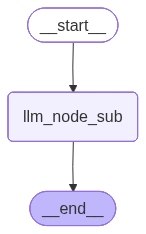

In [7]:
subgraph = StateGraph(AgentState)

subgraph.add_node('llm_node_sub', llm_node_sub)

subgraph.add_edge(START, 'llm_node_sub')
subgraph.add_edge('llm_node_sub', END)

translation_graph = subgraph.compile()

translation_graph

### Main graph

In [8]:
prompt = ChatPromptTemplate.from_messages(
    messages=[
        ('system', 'Answer the user question in simple words, in 2 - 3 lines max.'),
        ('user', 'Question: {question}')
    ]
)

chain = prompt | llm | StrOutputParser()

In [ ]:
def llm_node(state: AgentState) -> AgentState:
    ans = chain.invoke({
        'question': state['question']
    })
    print(ans)

    return {'eng_ans': ans}

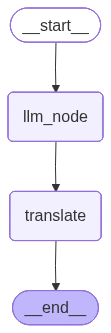

In [10]:
graph = StateGraph(AgentState)

graph.add_node('llm_node', llm_node)
graph.add_node('translate', translation_graph)

graph.add_edge(START, 'llm_node')
graph.add_edge('llm_node', 'translate')
graph.add_edge('translate', END)

main_graph = graph.compile()

main_graph

In [11]:
res = main_graph.invoke({'question': 'What is Claude Code?'})

print(f"User's question: {res['question']}", end = '\n\n')
print(f"Answer in english: {res['eng_ans']}", end = '\n\n')
print(f"Answer in bengali: {res['beng_ans']}")

{'question': 'What is Claude Code?'}
Claude Code is an AI-powered command-line tool that helps you write, debug, and manage your code directly in the terminal. It acts as an intelligent assistant that can analyze your project, run commands, and execute edits to speed up your development workflow.
User's question: What is Claude Code?

Answer in english: Claude Code is an AI-powered command-line tool that helps you write, debug, and manage your code directly in the terminal. It acts as an intelligent assistant that can analyze your project, run commands, and execute edits to speed up your development workflow.

Answer in bengali: ক্লোড কোড (Claude Code) হলো একটি এআই-চালিত কমান্ড-লাইন টুল, যা আপনাকে সরাসরি টার্মিনালে কোড লিখতে, ডিবাগ করতে এবং পরিচালনা করতে সাহায্য করে। এটি একটি বুদ্ধিমান সহকারী হিসেবে কাজ করে, যা আপনার ডেভেলপমেন্টের গতি বাড়াতে প্রজেক্ট বিশ্লেষণ করতে, কমান্ড চালাতে এবং কোডে প্রয়োজনীয় পরিবর্তন করতে সক্ষম।
